In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import least_squares
from mpl_toolkits.mplot3d import Axes3D

In [3]:
#modelo I vs T

def model_tiempo(t,
                  S0,
                  S1, S2, S3,
                  d1, d2, d3, d4,
                  T,
                  theta0):

    omega = 2*np.pi / T

    theta = omega*t + theta0

    theta_mod = theta % (2*np.pi)

    # delta por cuadrante
    delta = np.piecewise(
        theta_mod,
        [
            theta_mod < np.pi/2,

            (theta_mod >= np.pi/2)
            & (theta_mod < np.pi),

            (theta_mod >= np.pi)
            & (theta_mod < 3*np.pi/2),

            theta_mod >= 3*np.pi/2
        ],
        [d1, d2, d3, d4]
    )

    a0  = S0/2 + S1/4*(1 + np.cos(delta))

    a4c = S1/4*(1 - np.cos(delta))

    a4s = S2/4*(1 - np.cos(delta))

    a2  = -S3/2*np.sin(delta)

    return (
        a0
        + a2*np.sin(2*theta)
        + a4c*np.cos(4*theta)
        + a4s*np.sin(4*theta)
    )


In [4]:
#para una vuelta 

def fit_una_vuelta_tiempo(t, I, plot=True):

    # --------------------------------
    # ordenar por tiempo
    # --------------------------------
    idx = np.argsort(t)

    t = t[idx]
    I = I[idx]

    # --------------------------------
    # tiempo relativo
    # --------------------------------
    t = t - t.min()

    # --------------------------------
    # período
    # --------------------------------
    T = t.max() - t.min()

    # --------------------------------
    # normalización
    # --------------------------------
    I = I / np.max(I)

    S0 = np.max(I)

    # --------------------------------
    # errores
    # --------------------------------
    V_div = 0.005

    V_full_scale = 8 * V_div

    res_err = V_full_scale / 256

    I_err = np.sqrt(
        (0.03 * I)**2 + res_err**2
    )

    # --------------------------------
    # residuals
    # --------------------------------
    def residuals(params):

        S1, S2, S3, d1, d2, d3, d4, theta0 = params

        return (
            model_tiempo(
                t,
                S0,
                S1, S2, S3,
                d1, d2, d3, d4,
                T,
                theta0
            )
            - I
        ) / I_err

    # --------------------------------
    # condiciones iniciales
    # --------------------------------
    initial_guess = [

        0.1*S0,
        0.1*S0,
        0.1*S0,

        np.pi/2,
        np.pi/2,
        np.pi/2,
        np.pi/2,

        0
    ]

    # --------------------------------
    # bounds
    # --------------------------------
    lower_bounds = [

        -S0,
        -S0,
        -S0,

        0,
        0,
        0,
        0,

        -2*np.pi
    ]

    upper_bounds = [

        S0,
        S0,
        S0,

        2*np.pi,
        2*np.pi,
        2*np.pi,
        2*np.pi,

        2*np.pi
    ]

    # --------------------------------
    # fit
    # --------------------------------
    result = least_squares(
        residuals,
        initial_guess,
        bounds=(lower_bounds, upper_bounds)
    )

    # --------------------------------
    # parámetros
    # --------------------------------
    (
        S1_fit,
        S2_fit,
        S3_fit,
        d1_fit,
        d2_fit,
        d3_fit,
        d4_fit,
        theta0_fit

    ) = result.x

    # --------------------------------
    # errores
    # --------------------------------
    J = result.jac

    cov = (
        np.linalg.pinv(J.T @ J)
        * np.sum(result.fun**2)
        / (len(I) - len(result.x))
    )

    param_errors = np.sqrt(np.diag(cov))

    (
        S1_err,
        S2_err,
        S3_err,
        d1_err,
        d2_err,
        d3_err,
        d4_err,
        theta0_err

    ) = param_errors

    # --------------------------------
    # DOP
    # --------------------------------
    DOP = (
        np.sqrt(
            S1_fit**2
            + S2_fit**2
            + S3_fit**2
        )
        / S0
    )

    DOP_err = (

        1/S0

        * np.sqrt(
            (S1_fit*S1_err)**2
            + (S2_fit*S2_err)**2
            + (S3_fit*S3_err)**2
        )

        / np.sqrt(
            S1_fit**2
            + S2_fit**2
            + S3_fit**2
        )
    )

    # --------------------------------
    # vector de Poincaré
    # --------------------------------
    s1 = S1_fit / S0
    s2 = S2_fit / S0
    s3 = S3_fit / S0

    s1_err = S1_err / S0
    s2_err = S2_err / S0
    s3_err = S3_err / S0

    # --------------------------------
    # resultados
    # --------------------------------
    resultados = {

        "S0": S0,

        "S1": S1_fit,
        "S2": S2_fit,
        "S3": S3_fit,

        "S1_err": S1_err,
        "S2_err": S2_err,
        "S3_err": S3_err,

        "s1": s1,
        "s2": s2,
        "s3": s3,

        "s1_err": s1_err,
        "s2_err": s2_err,
        "s3_err": s3_err,

        "DOP": DOP,
        "DOP_err": DOP_err,

        "T": T,

        "theta0": theta0_fit,
        "theta0_err": theta0_err
    }

    # --------------------------------
    # plots
    # --------------------------------
    if plot:

        t_fit = np.linspace(
            t.min(),
            t.max(),
            1000
        )

        I_fit = model_tiempo(
            t_fit,

            S0,

            S1_fit,
            S2_fit,
            S3_fit,

            d1_fit,
            d2_fit,
            d3_fit,
            d4_fit,

            T,

            theta0_fit
        )

        plt.figure(figsize=(8,5))

        plt.errorbar(
            t,
            I,
            yerr=I_err,
            fmt='o',
            capsize=3,
            label='Datos'
        )

        plt.plot(
            t_fit,
            I_fit,
            label='Ajuste'
        )

        plt.xlabel("Tiempo")
        plt.ylabel("Intensidad")

        plt.grid()
        plt.legend()

        plt.show()

        # residuos
        residuos = (

            model_tiempo(
                t,

                S0,

                S1_fit,
                S2_fit,
                S3_fit,

                d1_fit,
                d2_fit,
                d3_fit,
                d4_fit,

                T,

                theta0_fit
            )

            - I
        )

        plt.figure(figsize=(8,4))

        plt.errorbar(
            t,
            residuos,
            yerr=I_err,
            fmt='o'
        )

        plt.axhline(
            0,
            linestyle='--'
        )

        plt.xlabel("Tiempo")
        plt.ylabel("Residuos")

        plt.grid()

        plt.show()

    return resultados

In [15]:
#para muchas vueltas

def fit_muchas_vueltas_tiempo(
        t_total,
        I_total,
        vueltas
):

    resultados = []

    for p in np.unique(vueltas):

        mask = vueltas == p

        t_vuelta = t_total[mask]

        I_vuelta = I_total[mask]

        res = fit_una_vuelta_tiempo(
            t_vuelta,
            I_vuelta,
            plot=False
        )

        resultados.append(res)

    return resultados

In [16]:
#para imprimir rdos y representarlos

def imprimir_resultados(res):

    print("\n===================================")
    print("      RESULTADOS DEL AJUSTE")
    print("===================================\n")

    print(f"S0 = {res['S0']:.5f}")

    print("\n--- Vector de Stokes ---\n")

    print(
        f"S1 = {res['S1']:.5f}"
        f" ± {res['S1_err']:.5f}"
    )

    print(
        f"S2 = {res['S2']:.5f}"
        f" ± {res['S2_err']:.5f}"
    )

    print(
        f"S3 = {res['S3']:.5f}"
        f" ± {res['S3_err']:.5f}"
    )

    print("\n--- Vector de Poincaré ---\n")

    print(
        f"s1 = {res['s1']:.5f}"
        f" ± {res['s1_err']:.5f}"
    )

    print(
        f"s2 = {res['s2']:.5f}"
        f" ± {res['s2_err']:.5f}"
    )

    print(
        f"s3 = {res['s3']:.5f}"
        f" ± {res['s3_err']:.5f}"
    )

    print("\n--- Polarización ---\n")

    print(
        f"DOP = {res['DOP']:.5f}"
        f" ± {res['DOP_err']:.5f}"
    )

    print("\n--- Rotación ---\n")

    print(
        f"T = {res['T']:.5f}"
    )

    print(
        f"theta0 = {res['theta0']:.5f}"
        f" ± {res['theta0_err']:.5f}"
    )

    print("\n===================================\n")


# ============================================================
# ESFERA DE POINCARÉ
# ============================================================

def plot_poincare_sphere(resultados):

    fig = plt.figure(figsize=(8,8))

    ax = fig.add_subplot(
        111,
        projection='3d'
    )

    # esfera
    u = np.linspace(0, 2*np.pi, 80)

    v = np.linspace(0, np.pi, 40)

    x = np.outer(np.cos(u), np.sin(v))
    y = np.outer(np.sin(u), np.sin(v))
    z = np.outer(np.ones_like(u), np.cos(v))

    ax.plot_wireframe(
        x,
        y,
        z,
        alpha=0.12
    )

    # ejes
    ax.plot([-1,1],[0,0],[0,0])
    ax.plot([0,0],[-1,1],[0,0])
    ax.plot([0,0],[0,0],[-1,1])

    # puntos
    for i, res in enumerate(resultados):

        s1 = res["s1"]
        s2 = res["s2"]
        s3 = res["s3"]

        ax.scatter(
            s1,
            s2,
            s3,
            s=80,
            c=[i],
            cmap='viridis'
        )

        ax.plot(
            [0,s1],
            [0,s2],
            [0,s3],
            '--'
        )

    ax.set_xlabel("s1")
    ax.set_ylabel("s2")
    ax.set_zlabel("s3")

    ax.set_xlim(-1,1)
    ax.set_ylim(-1,1)
    ax.set_zlim(-1,1)

    ax.set_box_aspect((1,1,1))

    ax.set_title("Esfera de Poincaré")

    plt.show()

## Implemento codigo 

In [ ]:
#1 vuelta

medicion = pd.read_csv("Measurements/una_vuelta.csv")

t = medicion["tiempo"].values

I = medicion["intensidad"].values

res = fit_una_vuelta_tiempo(
    t,
    I
)

imprimir_resultados(res)

plot_poincare_sphere([res])

In [ ]:
#muchas vueltas

medicion = pd.read_csv("Measurements/muchas_vueltas.csv")

t_total = medicion["tiempo"].values

I_total = medicion["intensidad"].values

periodos = medicion["periodo"].values

resultados = fit_muchas_vueltas_tiempo(
    t_total,
    I_total,
    periodos
)

for i, res in enumerate(resultados):

    print(f"\n######## VUELTA {i} ########")

    imprimir_resultados(res)

plot_poincare_sphere(resultados)

## Analisis datos

In [72]:
#leo datos y defino variables

medicion = pd.read_csv('Pico Code\\datos_motor.csv')
#time_us,adc_raw,iman,periodo_us
time=np.array(medicion['time_us'])
voltaje=np.array(medicion['adc_raw'])
tick=np.array(medicion['iman'])
tau=np.array(medicion['periodo_us'])
medicion.head()

,time_us,adc_raw,iman,periodo_us
0,70,912,0,0
1,4346,944,0,0
2,8345,1136,0,0
3,12321,1248,0,0
4,16310,944,0,0


In [73]:
#quiero un array con el tiempo de cada tick correspondiente
time_ticks=np.array(time[tick == 1]) #tick==1  hace que el array ticks se convierta en uno que diga false cuando es 0 y true cuando diga 1 
#y despues me quedo con los times donde sea true, osea los tiempos del tick 
print(time_ticks)
    

[  20287  131782  243278  358757  478216  585728  701210  816689  927463
 1042939 1162399 1269917]


In [74]:
# #ahora la idea es hacer un array que diga cada item a que vuelta corresponde, entonces cada valor de intensidad segun su tiempo pertenece a  la vuelta correspondiente
# vueltas = np.zeros(len(time), dtype=int)

# inicio = 0

# for i, fin in enumerate(time_ticks):

#     mask = (time >= inicio) & (time < fin)

#     vueltas[mask] = i

#     inicio = fin

vueltas = np.full(len(time), -1, dtype=int)

inicio = 0

for i, fin in enumerate(time_ticks):

    mask = (time >= inicio) & (time < fin)

    vueltas[mask] = i

    inicio = fin

# lo que queda después del último tick
mask_final = time >= time_ticks[-1]

vueltas[mask_final] = vueltas.max() + 1

In [45]:
print(vueltas)

[ 0  0  0  0  0  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2
  2  2  2  2  2  2  2  2  2  2  2  2  2  3  3  3  3  3  3  3  3  3  3  3
  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  4  4  4  4  4  4
  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4
  5  5  5  5  5  5  5  5  5  5  5  5  5  5  5  5  5  5  5  5  5  5  5  5
  5  5  5  6  6  6  6  6  6  6  6  6  6  6  6  6  6  6  6  6  6  6  6  6
  6  6  6  6  6  6  6  6  7  7  7  7  7  7  7  7  7  7  7  7  7  7  7  7
  7  7  7  7  7  7  7  7  7  7  7  7  7  8  8  8  8  8  8  8  8  8  8  8
  8  8  8  8  8  8  8  8  8  8  8  8  8  8  9  9  9  9  9  9  9  9  9  9
  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9 10 10 10 10 10
 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10
 10 11 11 11 11 11 11 11 11 11 11 11 11 11 11 11 11 11 11 11 11 11 11 11
 11 11 11 11 12 12 12 12 12 12 12]


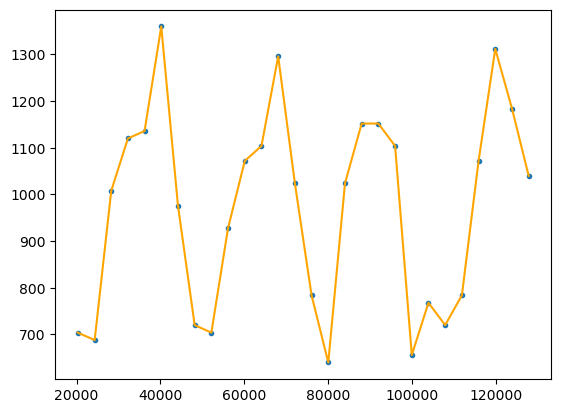

In [75]:
#quiero graficar que onda una vuelta, la intensidad en funcion del tiempo que deberia de ser sinusoidal si o si
time_1v=time[vueltas==1]
voltaje_1v=voltaje[vueltas==1]
plt.plot(time_1v,voltaje_1v,".")
plt.plot(time_1v,voltaje_1v,"-",color="orange")

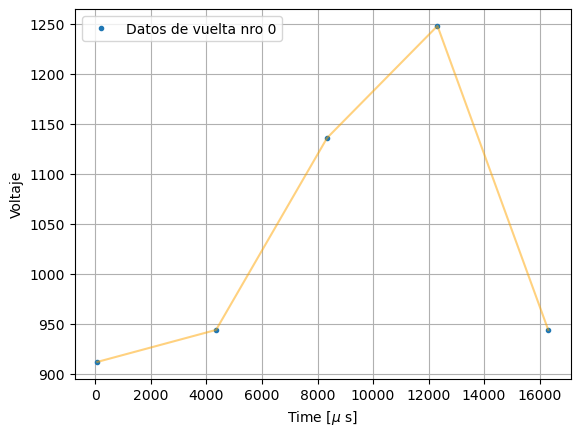

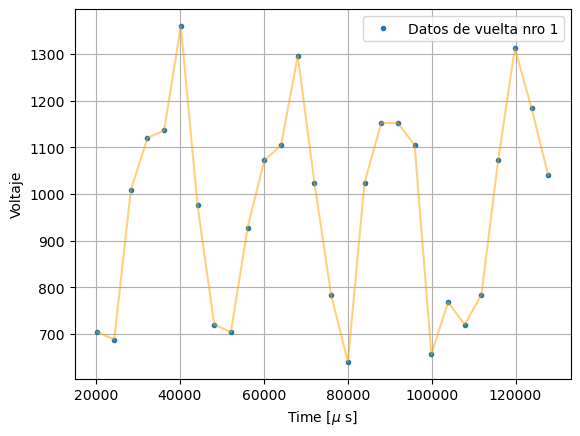

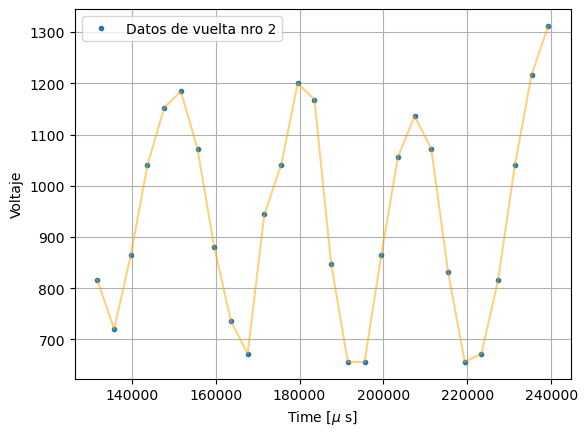

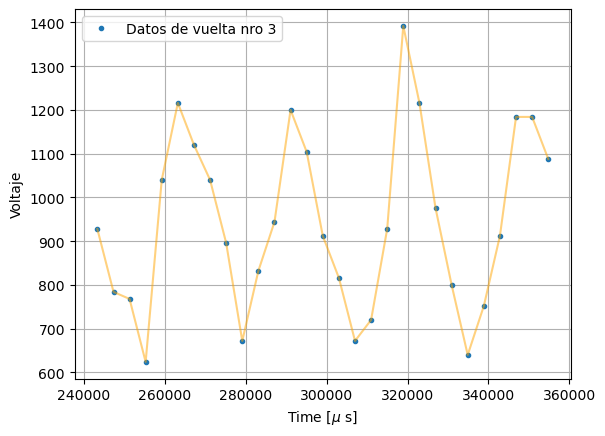

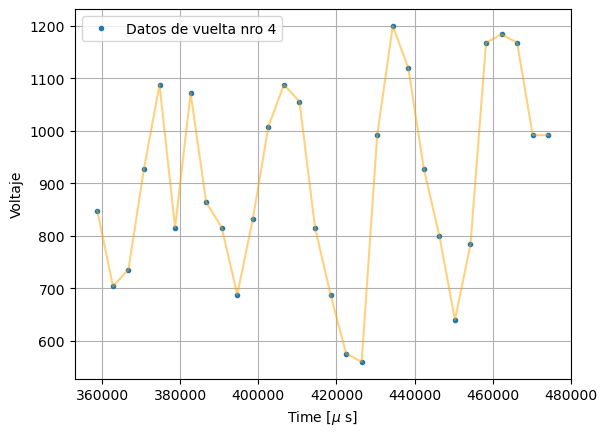

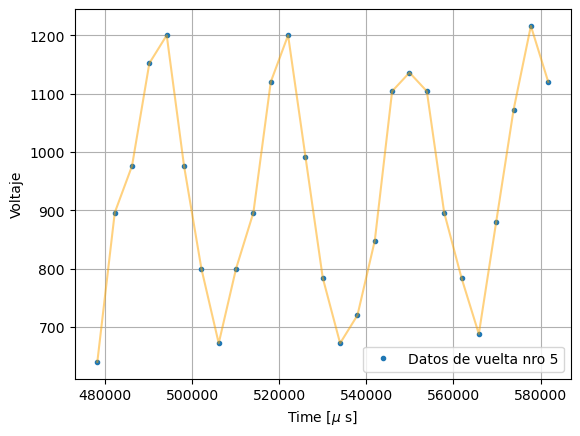

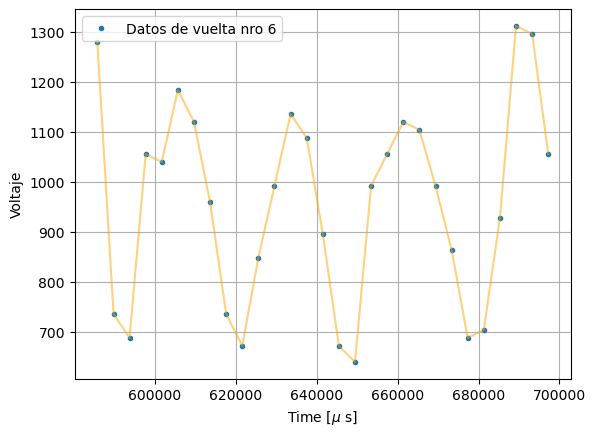

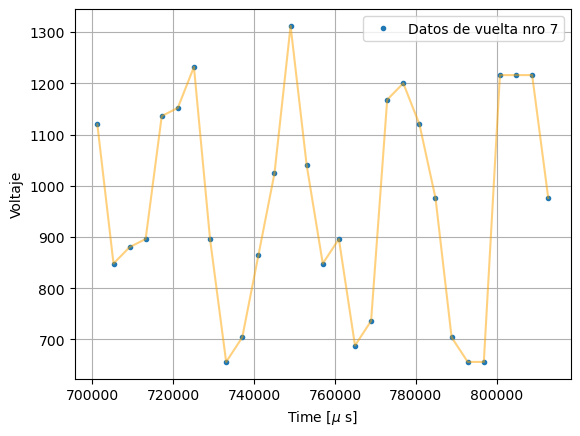

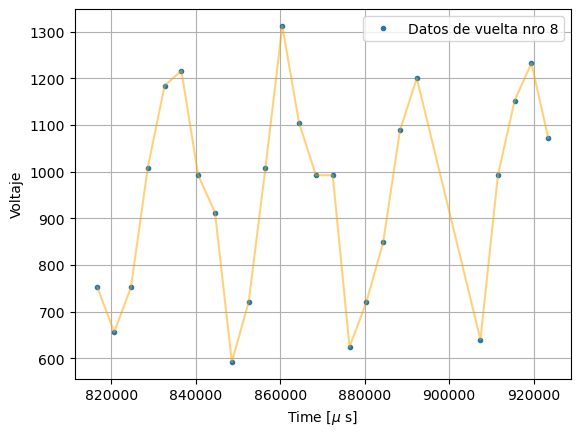

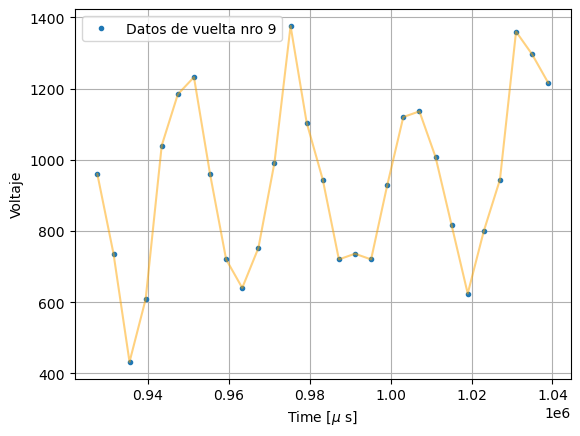

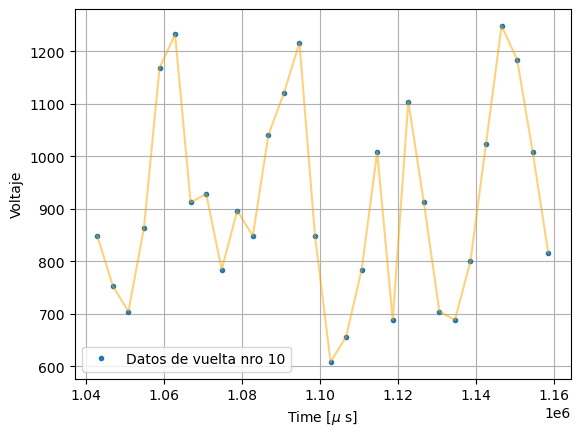

In [68]:
for i in range(0,11):
    time_i=time[vueltas==i]
    volt_i=voltaje[vueltas==i]
    plt.figure()
    plt.plot(time_i,volt_i,".",label=f"Datos de vuelta nro {i}")
    plt.plot(time_i,volt_i,"-",color="orange",alpha=0.5)
    plt.xlabel(r"Time [$\mu$ s]")
    plt.ylabel("Voltaje")
    plt.grid()
    plt.legend()

## Ajusto

In [ ]:
# vueltas=vueltas[4:]
# time=time[4:]
# voltaje=voltaje[4:]

C:\Users\barcr\AppData\Local\Temp\ipykernel_28320\4125496164.py:145: RuntimeWarning: invalid value encountered in sqrt
  param_errors = np.sqrt(np.diag(cov))



######## VUELTA 0 ########

      RESULTADOS DEL AJUSTE

S0 = 1.00000

--- Vector de Stokes ---

S1 = 0.33877 ± nan
S2 = 0.93911 ± nan
S3 = 0.05753 ± nan

--- Vector de Poincaré ---

s1 = 0.33877 ± nan
s2 = 0.93911 ± nan
s3 = 0.05753 ± nan

--- Polarización ---

DOP = 1.00000 ± nan

--- Rotación ---

T = 16240.00000
theta0 = 0.27995 ± nan



######## VUELTA 1 ########

      RESULTADOS DEL AJUSTE

S0 = 1.00000

--- Vector de Stokes ---

S1 = 0.79667 ± 0.06900
S2 = 0.01998 ± 0.13988
S3 = 0.86339 ± 0.86107

--- Vector de Poincaré ---

s1 = 0.79667 ± 0.06900
s2 = 0.01998 ± 0.13988
s3 = 0.86339 ± 0.86107

--- Polarización ---

DOP = 1.17496 ± 0.63447

--- Rotación ---

T = 107514.00000
theta0 = -1.01680 ± 0.04945



######## VUELTA 2 ########

      RESULTADOS DEL AJUSTE

S0 = 1.00000

--- Vector de Stokes ---

S1 = 0.72978 ± 0.12424
S2 = -0.32906 ± 0.60625
S3 = -0.17437 ± 0.23608

--- Vector de Poincaré ---

s1 = 0.72978 ± 0.12424
s2 = -0.32906 ± 0.60625
s3 = -0.17437 ± 0.23608

--- Pola

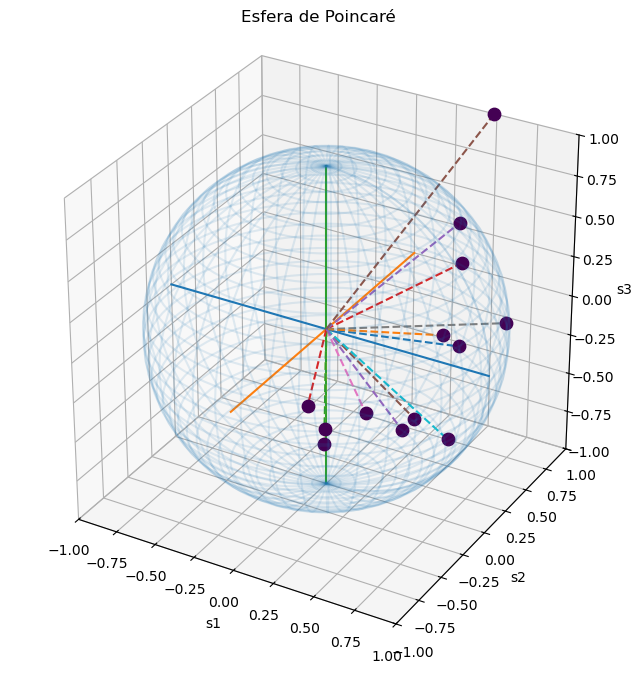

In [76]:
resultados = fit_muchas_vueltas_tiempo(
    time,
    voltaje,
    vueltas
)

for i, res in enumerate(resultados):

    print(f"\n######## VUELTA {i} ########")

    imprimir_resultados(res)

plot_poincare_sphere(resultados)

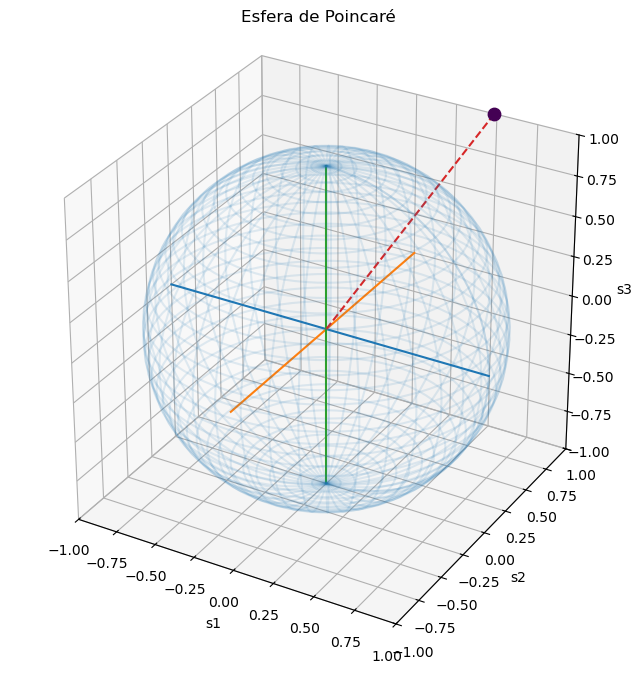

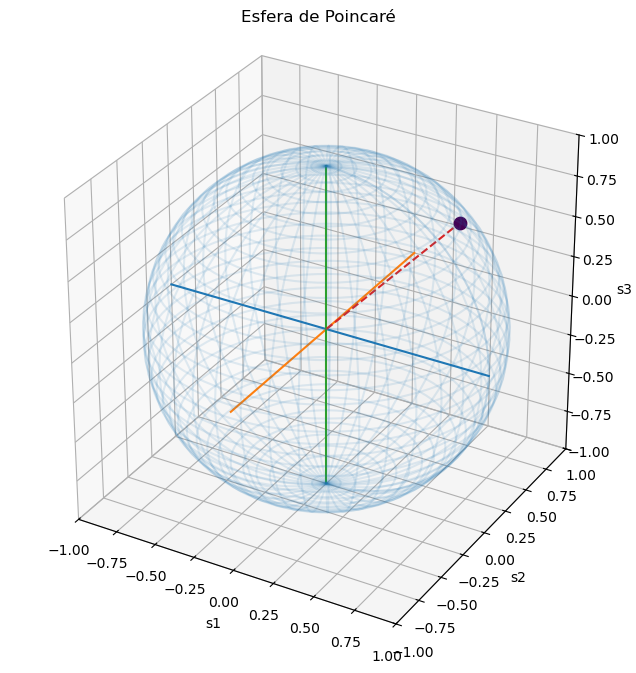

In [86]:
plot_poincare_sphere([resultados[12]])
plot_poincare_sphere([resultados[1]])